In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e7/train.csv
/kaggle/input/competitions/playground-series-s6e7/test.csv


EDA

In [2]:
import pandas as pd
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")

Size

In [3]:
train.shape
test.shape

(295753, 14)

head and first row

In [4]:
train.head(10)    

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
5,5,at-risk,5.11,82.8,24.43,2290.0,2134.0,29.2,2.02,veg,low,poor,sedentary,occasional,male
6,6,at-risk,8.21,71.1,24.14,2723.0,12984.0,54.5,2.01,balanced,low,NaN,moderate,no,female
7,7,at-risk,7.47,87.0,23.51,NaN,3096.0,37.5,0.51,balanced,low,average,sedentary,occasional,male
8,8,unhealthy,5.94,75.4,24.36,NaN,12165.0,61.6,1.56,veg,high,average,active,no,other
9,9,at-risk,6.97,80.1,20.47,2928.0,13108.0,51.9,2.53,veg,medium,good,active,no,male


In [5]:
test.head(10)

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
5,690093,8.51,72.0,21.96,2449.0,7232.0,49.9,2.56,balanced,NaN,poor,active,occasional,male
6,690094,6.21,65.6,25.02,1788.0,4884.0,48.5,2.01,veg,high,average,moderate,yes,male
7,690095,7.17,65.7,NaN,NaN,14082.0,NaN,1.14,veg,high,average,NaN,NaN,male
8,690096,7.95,61.1,22.16,NaN,3228.0,0.0,2.60,balanced,high,good,sedentary,no,male
9,690097,NaN,73.7,21.89,2121.0,8961.0,43.7,3.55,veg,NaN,average,moderate,no,NaN


In [6]:
test.tail(5)

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female
295752,985840,4.61,85.1,23.79,2456.0,14195.0,50.5,2.30,non-veg,high,average,active,occasional,other


In [7]:
train.tail(5)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
690083,690083,at-risk,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,at-risk,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,fit,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,at-risk,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male
690087,690087,at-risk,5.55,69.3,24.38,2257.0,5144.0,47.9,1.76,balanced,medium,average,moderate,yes,male


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       295753 non-null  int64  
 1   sleep_duration           263182 non-null  float64
 2   heart_rate               292396 non-null  float64
 3   bmi                      289797 non-null  float64
 4   calorie_expenditure      273101 non-null  float64
 5   step_count               289789 non-null  float64
 6   exercise_duration        292795 non-null  float64
 7   water_intake             277120 non-null  float64
 8   diet_type                292795 non-null  object 
 9   stress_level             260263 non-null  object 
 10  sleep_quality            270754 non-null  object 
 11  physical_activity_level  280058 non-null  object 
 12  smoking_alcohol          283504 non-null  object 
 13  gender                   286593 non-null  object 
dtypes: f

In [10]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

check null

In [11]:
test.isnull().sum()

id                             0
sleep_duration             32571
heart_rate                  3357
bmi                         5956
calorie_expenditure        22652
step_count                  5964
exercise_duration           2958
water_intake               18633
diet_type                   2958
stress_level               35490
sleep_quality              24999
physical_activity_level    15695
smoking_alcohol            12249
gender                      9160
dtype: int64

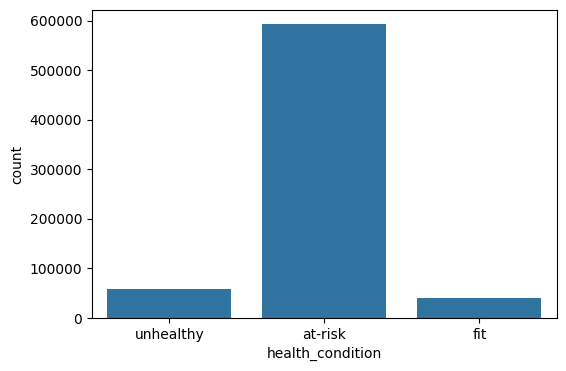

In [12]:
#understanding the targets
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=train,x="health_condition")
plt.show()

In [13]:
num_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake",
    "stress_level"
]

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


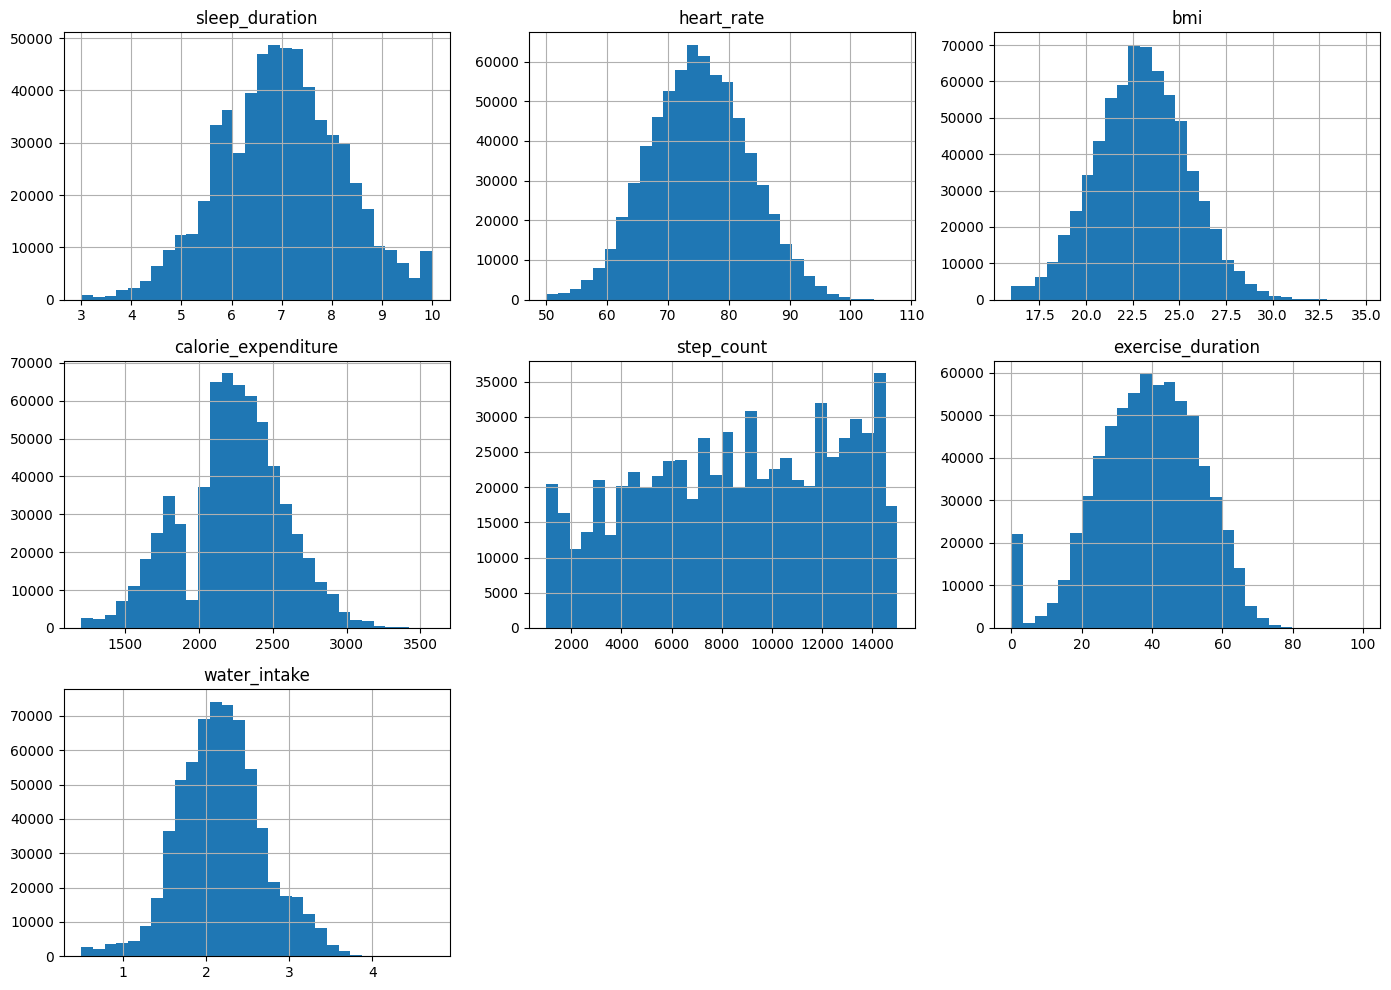

In [14]:
train[num_cols].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()
plt.show()

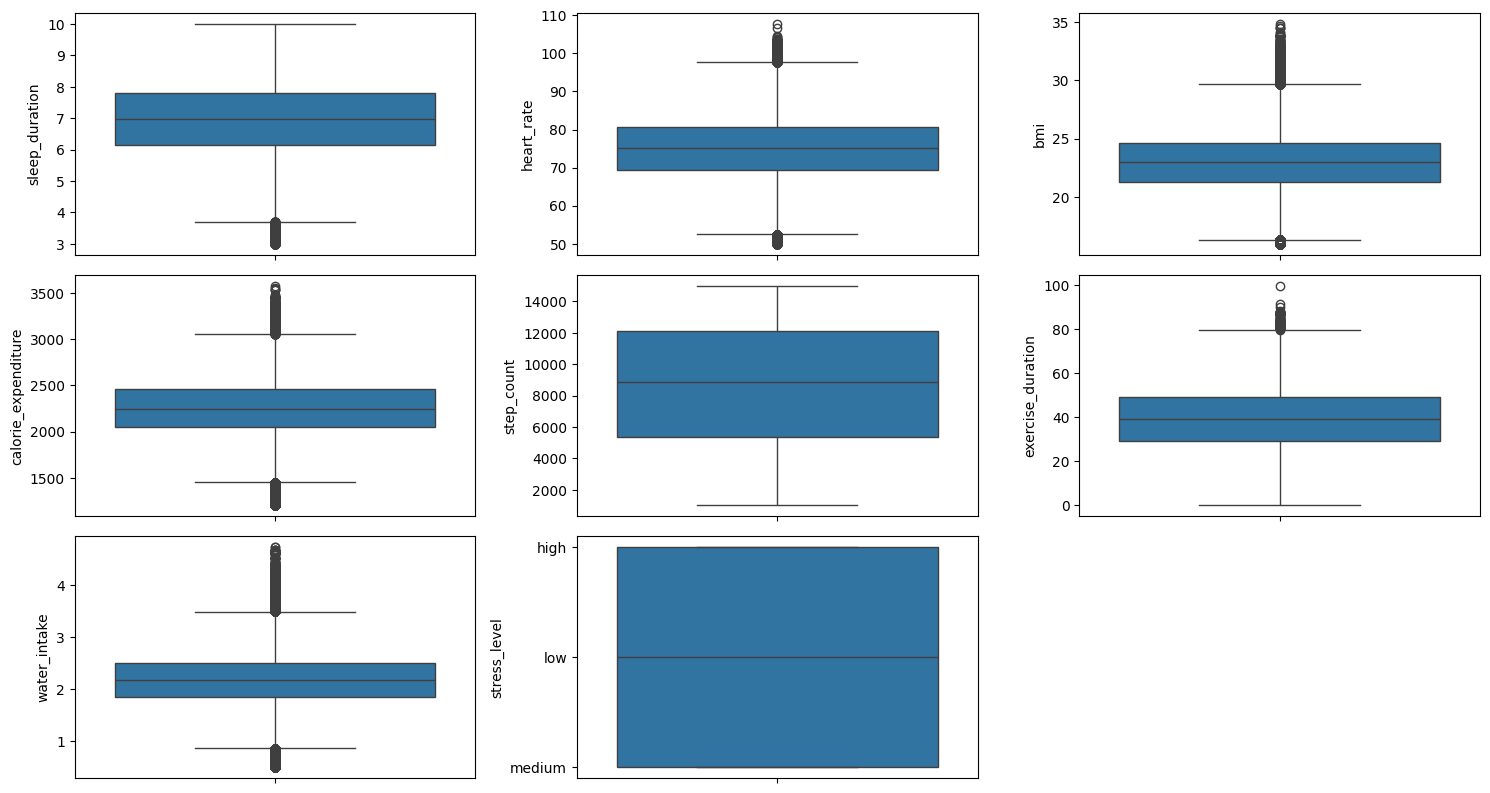

In [15]:
plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=train[col])

plt.tight_layout()

In [16]:
train["diet_type"].value_counts()

diet_type
veg         231432
balanced    226888
non-veg     224867
Name: count, dtype: int64